## The SARIMA Model (Adding seasonality (S) to the ARIMA model)

The power of the SARIMA model is that it needs to use only the history of the target 
variable, which can be applied to very many cases of forecasting. Within univariate 
time series modeling, the SARIMA model is the most complete model, using AR, MA, 
integration for modeling trends, and seasonality.

The `MODEL formular` is on page 116.

In this model, you can observe the following parts:
* The regular AR part, with the coefficients φp (small phis)
* The seasonal AR part, with the coefficients φ
 (capital phis)
* The regular MA part, with the coefficients θq (small thetas)
* The seasonal MA part, with the coefficients θ
 (capital thetas)
* The regular integration part, indicated by order d
* The seasonal integration part, indicated by order D
* Coefficient of seasonality s


The same hyperparameters as before still need to be decided on:
* p for the AR order
* q for the MA order
* I for the differencing order

To this are added three more orders:


* P for the seasonal AR order
* Q for the seasonal MA order
* D for the seasonal differencing

the parameter `s` is the seasonal period. This `s` is not 
a hyperparameter like the other orders. `s` should not be tested using a grid search; rather, it 
should be decided based on logic. The `s` is the periodicity of the seasonality. If you work with 
monthly data, you should choose 12; if you work with weekly data, you should choose 52.

### SARIMA on Walmart Sales

We will apply SARIMA on walmart sales store forcasting dataset.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv('../database/walmart-recruiting-store-sales-forecasting-Copy/train.csv/train.csv')
data

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False
...,...,...,...,...,...
421565,45,98,2012-09-28,508.37,False
421566,45,98,2012-10-05,628.10,False
421567,45,98,2012-10-12,1061.02,False
421568,45,98,2012-10-19,760.01,False


In [2]:
data = data.groupby('Date').sum()
data

,Store,Dept,Weekly_Sales,IsHoliday
Date,,,,
2010-02-05,65124,130557,49750740.50,0
2010-02-12,65082,131179,48336677.63,2956
2010-02-19,65610,131897,48276993.78,0
2010-02-26,65045,130161,43968571.13,0
2010-03-05,64897,129670,46871470.30,0
...,...,...,...,...
2012-09-28,65866,130785,43734899.40,0
2012-10-05,66296,132468,47566639.31,0
2012-10-12,66453,133371,46128514.25,0


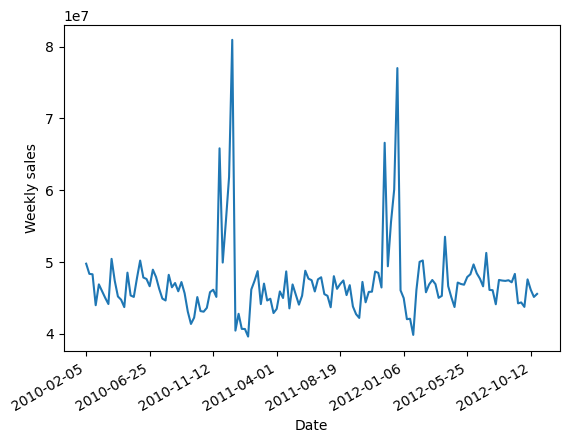

In [3]:
ax = data['Weekly_Sales'].plot()
ax.set_ylabel('Weekly sales')
plt.gcf().autofmt_xdate()
plt.show()

Let’s first try a first model: `SARIMA(1,1,1)(1,1,1)52`. This notation indicates an 
order 1 for each of the hyperparameters. The seasonality is 52, because we’re working 
with weekly data. We will be forecasting ten steps out rather than doing ten one-step 
forecasts. This is a case of multistep forecasting

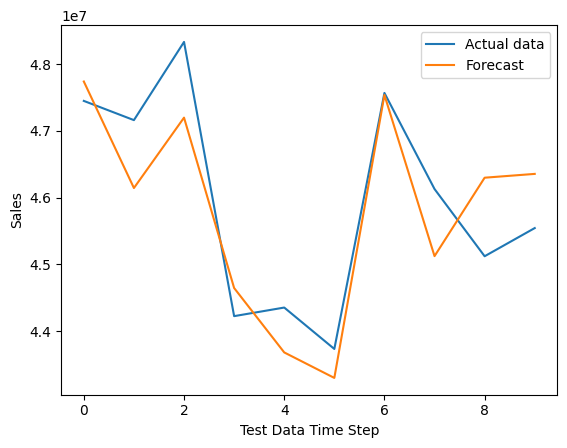

0.7309576477136897

In [4]:
# Fitting a SARIMA(1,1,1)(1,1,1)52 model
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score

import warnings

warnings.filterwarnings('ignore')


train = data['Weekly_Sales'][:-10]
test = data['Weekly_Sales'][-10:]

mod = SARIMAX(train, order=(1,1,1), 
seasonal_order=(1,1,1,52))

res = mod.fit(disp=False)
fcst = res.forecast(steps=10) ## we are forecasting 10 ahead instead of retraining cycle used in last topic. This is because this one will capture the seasonality as well

plt.plot(list(test))
plt.plot(list(fcst))
plt.legend(['Actual data', 'Forecast'])
plt.ylabel('Sales')
plt.xlabel('Test Data Time Step')
plt.show()
r2_score(test, fcst)

In this version, without any hyperparameter optimization, the SARIMA model 
obtains an R2 score of `0.73`. This means that the model can explain 73% of the variation 
in the test data. This is a very promising score.

The reason that this score is already quite good is probably the flexibility of the 
SARIMA model. The fact that it is a combination of multiple effects makes it fit to many 
different underlying processes. We will now see how this score can improve using a grid 
search of the hyperparameters.

To speed up the code, we will not use cross-validation in the grid search here. Speed 
of execution is also an important aspect of machine learning. As a second optimization, 
we will be working with a ten-step forecast rather than with ten updated steps of a  
one- step forecast. In this way, it will be interesting to see how the seasonal effects may be 
more efficient in capturing long-term trends.

In [5]:
# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(2):
    for i in range(2):
        for q in range(2):
            for P in range(2):
                for D in range(2):
                    for Q in range(2):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,52))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except:
                            print('errored')


[0, 0, 0, 0, 0, 0, -907.1066113344237]
[0, 0, 0, 0, 0, 1, -400.0926553357708]
[0, 0, 0, 0, 1, 0, 0.3708213108942816]
[0, 0, 0, 0, 1, 1, 0.3702845954113335]
[0, 0, 0, 1, 0, 0, 0.34152742061742747]
[0, 0, 0, 1, 0, 1, 0.11460883725488213]
[0, 0, 0, 1, 1, 0, 0.3704996255051265]
[0, 0, 0, 1, 1, 1, 0.6095396174517633]
[0, 0, 1, 0, 0, 0, -833.3919832484671]
[0, 0, 1, 0, 0, 1, -507.00892037897813]
[0, 0, 1, 0, 1, 0, 0.37079253060820216]
[0, 0, 1, 0, 1, 1, 0.3703638764741932]
[0, 0, 1, 1, 0, 0, -322.3662001586125]
[0, 0, 1, 1, 0, 1, -303.4843741877086]
[0, 0, 1, 1, 1, 0, 0.3705199850138]
[0, 0, 1, 1, 1, 1, 0.6052323988310128]
[0, 1, 0, 0, 0, 0, -0.8332866985703771]
[0, 1, 0, 0, 0, 1, -0.15501515698710122]
[0, 1, 0, 0, 1, 0, 0.5924046391246292]
[0, 1, 0, 0, 1, 1, 0.6231533302890921]
[0, 1, 0, 1, 0, 0, 0.7170897686601474]
[0, 1, 0, 1, 0, 1, 0.6128799894477199]
[0, 1, 0, 1, 1, 0, 0.6050986889599668]
[0, 1, 0, 1, 1, 1, 0.7187531535927048]
[0, 1, 1, 0, 0, 0, -0.6610098810669516]
[0, 1, 1, 0, 0, 1, -

It is obcious the best performance was [0, 1, 1, 1, 1, 1, 0.7343408618799898]. it is just slightly above but this is just for training exercises. We can increase the number of hyperparameter iterations to check better hyperparameters. 

In [8]:
res = pd.DataFrame(scores)
res.columns = ['p', 'i', 'q', 'P', 'D', 'Q', 'score']
result = res.sort_values('score')

In [9]:
result

,p,i,q,P,D,Q,score
0,0,0,0,0,0,0,-907.106611
8,0,0,1,0,0,0,-833.391983
9,0,0,1,0,0,1,-507.008920
1,0,0,0,0,0,1,-400.092655
12,0,0,1,1,0,0,-322.366200
...,...,...,...,...,...,...,...
20,0,1,0,1,0,0,0.717090
23,0,1,0,1,1,1,0.718753
63,1,1,1,1,1,1,0.730958
55,1,1,0,1,1,1,0.733406


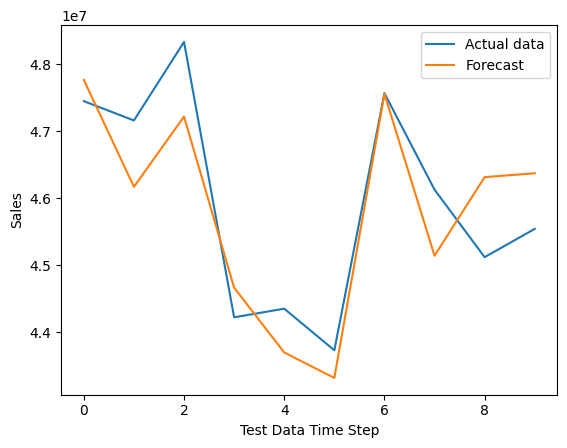

0.7343408618799898

In [10]:
## Plot the best output
train = data['Weekly_Sales'][:-10]
test = data['Weekly_Sales'][-10:]

mod = SARIMAX(train, order=(0,1,1), 
seasonal_order=(1,1,1,52))

res = mod.fit(disp=False)
fcst = res.forecast(steps=10) ## we are forecasting 10 ahead instead of retraining cycle used in last topic. This is because this one will capture the seasonality as well

plt.plot(list(test))
plt.plot(list(fcst))
plt.legend(['Actual data', 'Forecast'])
plt.ylabel('Sales')
plt.xlabel('Test Data Time Step')
plt.show()
r2_score(test, fcst)

### Key Takeaways
* The SARIMA model adds a seasonal effect to the ARIMA model.
* The SARIMA model is the completest version of univariate time 
series models.
* There are four more hyperparameters in the SARIMA model:
* Seasonal AR order
* Seasonal MA order
* Seasonal integration order
* Periodicity (based on the number of periods that a seasonality 
would logically return)